# Diptera wing classification using Topological Data Analysis

Guilherme Vituri F. Pinto [](https://orcid.org/0000-0002-7813-8777) (Universidade Estadual Paulista)  
Sergio UraNorthonApril 27, 2026

We use Topological Data Analysis (TDA) to describe Diptera wing venation and classify specimens at the family level. From 70 binarized wing images representing nine families, we extract two compact persistence summaries: H1 persistence from Vietoris-Rips filtrations of point-cloud samples and H0 persistence from radial filtrations of connected wing images. These 34 topological features are evaluated with a single balanced Random Forest model using repeated stratified 3-fold cross-validation. Because the dataset is imbalanced, performance is summarized primarily with macro-F1, macro-recall, family-level recall, and a row-normalized confusion matrix. We also use a feature-reduction screen to identify a smaller candidate set of topological summaries for biological interpretation. A direct Wasserstein-distance baseline on Rips persistence diagrams is competitive with the Random Forest, suggesting that much of the taxonomic signal is already present in the Rips diagrams themselves.

In [2]:
import Pkg
Pkg.activate(pwd())

using TDAfly: findall_ids
using TDAfly.Preprocessing: connect_pixel_components, image_to_array, image_to_r2, load_wing
using TDAfly.TDA: pd_statistics_extended, radial_filtration, radial_pd_0d, rips_pd_1d
using TDAfly.Analysis: classification_metrics, confusion_matrix, sanitize_distance_matrix, sanitize_feature_matrix
using DataFrames
using DecisionTree
using DecisionTree: apply_forest, build_forest, build_tree
using MetricSpaces: farthest_points_sample
using PersistenceDiagrams: Wasserstein, persistence
using Plots: bar, default, display, heatmap, hline!, plot, plot!
using ProgressMeter: @showprogress
using Random: MersenneTwister, shuffle!
using Statistics: mean, std
using StatsPlots: boxplot

# Use raster plots for notebook frontends that may mis-render large vector output.
default(fmt = :png, dpi = 120, size = (720, 460))

<style>
.cell-output-display img,
.quarto-figure img {
  max-width: 100%;
  height: auto;
}
</style>

In [3]:
CV_K = 3
CV_REPEATS = 30
RF_N_TREES = 500
RF_MAX_DEPTH = -1
RF_MIN_SAMPLES_LEAF = 1
RNG_SEED = 20260223
FEATURE_SCREEN_REPEATS = 10
FEATURE_SCREEN_N_TREES = 250
FEATURE_PERFORMANCE_TOLERANCE = 0.01

0.01

## Introduction

Diptera wing venation is a classical taxonomic character: the arrangement of veins and enclosed cells varies among families and provides a natural morphological signature. Topological Data Analysis (TDA) is well suited to this problem because persistent homology summarizes connected components and loops in a way that is less tied to exact pixel coordinates than many raw image descriptors.

We use two complementary filtrations: a Vietoris-Rips filtration on point-cloud samples of each wing, retaining H1 persistence to describe global loops; and a radial filtration on the connected binary wing image, retaining H0 persistence to describe how vein components merge from the center of the wing outward.

The statistical goal is to test whether compact topological summaries carry family-level signal and to identify which summaries are most useful for prediction. To keep the validation aligned with the small and imbalanced dataset, we evaluate one balanced Random Forest model with repeated stratified 3-fold cross-validation and report macro-F1, macro-recall, family-level recall, and the confusion matrix.

## Methods

### Data and preprocessing

All wing images are stored in `images/processed`. File names encode the family and specimen identifier. We standardize family names, remove duplicated files that differ only by spacing or spelling variants, blur each image slightly, crop it, and resize it to 150 pixels in height.

In [4]:
all_paths = sort(readdir("images/processed", join = true))
all_filenames = basename.(all_paths) .|> (x -> replace(x, ".png" => ""))

function extract_family(name)
    family_raw = lowercase(split(name, r"[\s\-]")[1])
    if family_raw in ("bibionidae", "biobionidae")
        return "Bibionidae"
    elseif family_raw in ("sciaridae", "scaridae")
        return "Sciaridae"
    elseif family_raw == "simulidae"
        return "Simuliidae"
    else
        return titlecase(family_raw)
    end
end

function canonical_id(name)
    family = extract_family(name)
    specimen_number = split(name, r"[\s\-]")[end]
    "$(family)-$(specimen_number)"
end

seen = Set{String}()
keep_idx = Int[]
for (i, fname) in enumerate(all_filenames)
    cid = canonical_id(fname)
    if !(cid in seen)
        push!(seen, cid)
        push!(keep_idx, i)
    end
end

paths = all_paths[keep_idx]
species = all_filenames[keep_idx]
families = extract_family.(species)
individuals = map(species) do specimen
    specimen_number = split(specimen, r"[\s\-]")[end]
    string(extract_family(specimen)[1]) * "-" * specimen_number
end

dataset_df = DataFrame(family = families)
family_counts_df = combine(groupby(dataset_df, :family), nrow => :n)
sort!(family_counts_df, :family)

println("Total images after deduplication: $(length(paths))")
println("Number of families: $(length(unique(families)))")
family_counts_df

Total images after deduplication: 70
Number of families: 9

In [5]:
wings = load_wing.(paths, blur = 1.8)
Xs = map(wings) do wing
    image_to_r2(wing; threshold = 0.08, ensure_connected = true, connectivity = 8)
end;

### Topological feature extraction

We compute two persistence diagrams for each wing. First, we sample 750 points from the wing point cloud and compute H1 persistence from the Vietoris-Rips filtration. Second, we construct a connected binary image and compute H0 persistence from the radial filtration.

> **Persistent homology overview**
>
> Persistent homology tracks topological features as a filtration parameter changes. H0 records connected components; H1 records loops. Long-lived features are treated as more stable shape information than short-lived features.

In [6]:
samples = Vector{Any}(undef, length(Xs))
Threads.@threads for i in eachindex(Xs)
    samples[i] = farthest_points_sample(Xs[i], 750)
end

pds_rips = @showprogress "rips_h1" map(samples) do sample
    rips_pd_1d(sample, cutoff = 5, threshold = 200)
end;

In [7]:
function make_connected_array(wing; threshold = 0.08, connectivity = 8)
    rows, cols = size(wing)
    ids = findall_ids(>(threshold), image_to_array(wing))
    ids_conn = connect_pixel_components(ids; connectivity = connectivity)
    A = ones(Float64, rows, cols)
    for p in ids_conn
        A[p[1], p[2]] = 0.0
    end
    A
end

wing_arrays = [make_connected_array(wing) for wing in wings]

pds_radial_h0 = @showprogress "radial_h0" map(wing_arrays) do A
    radial_pd_0d(A)
end;

The plots below show three representative wings, their radial filtration, and the largest persistence values from each retained diagram.


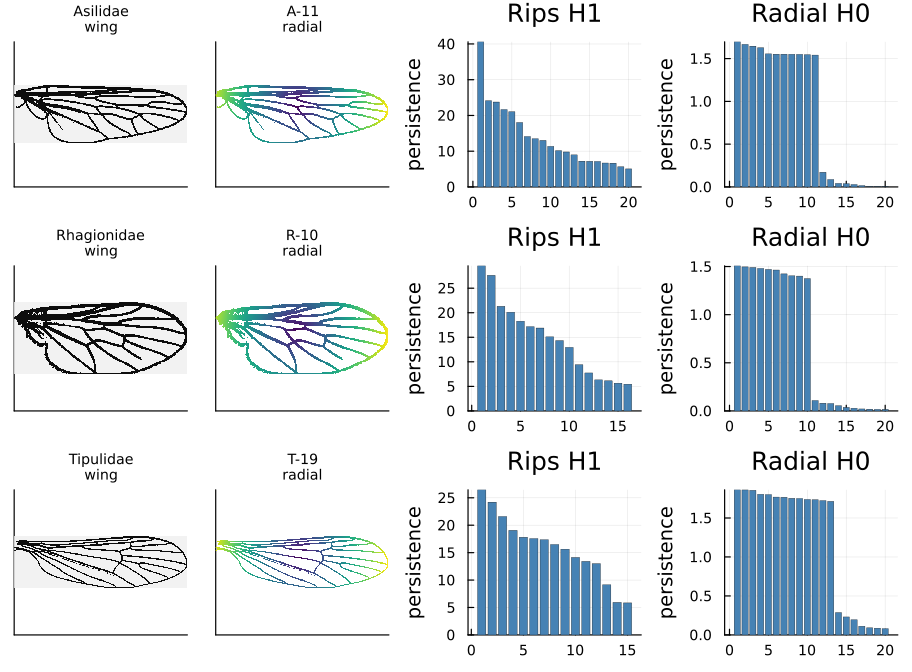

In [8]:
function wing_panel(idx; title_str = "")
    heatmap(
        wing_arrays[idx][end:-1:1, :],
        color = :grays,
        colorbar = false,
        aspect_ratio = :equal,
        xticks = false,
        yticks = false,
        title = title_str,
        titlefontsize = 8,
    )
end

function radial_panel(idx; title_str = "")
    F = radial_filtration(wing_arrays[idx])
    F_display = copy(F)
    F_display[F_display .> 1.5] .= NaN
    heatmap(
        F_display[end:-1:1, :],
        color = :viridis,
        colorbar = false,
        aspect_ratio = :equal,
        xticks = false,
        yticks = false,
        title = title_str,
        titlefontsize = 8,
    )
end

function persistence_bar(values; title_str)
    finite_values = sort([v for v in values if isfinite(v)], rev = true)
    finite_values = finite_values[1:min(20, length(finite_values))]
    if isempty(finite_values)
        return plot(title = title_str, legend = false)
    end
    bar(
        finite_values,
        title = title_str,
        ylabel = "persistence",
        legend = false,
        color = :steelblue,
        linecolor = :black,
        linewidth = 0.25,
    )
end

example_families = sort(unique(families))[[1, cld(length(unique(families)), 2), length(unique(families))]]
example_indices = [findfirst(==(family), families) for family in example_families]

example_plots = Any[]
for idx in example_indices
    push!(example_plots, wing_panel(idx; title_str = "$(families[idx])\nwing"))
    push!(example_plots, radial_panel(idx; title_str = "$(individuals[idx])\nradial"))
    push!(example_plots, persistence_bar(persistence.(pds_rips[idx]); title_str = "Rips H1"))
    radial_persistence = [persistence(x) for x in pds_radial_h0[idx]]
    push!(example_plots, persistence_bar(radial_persistence; title_str = "Radial H0"))
end

plot(example_plots..., layout = (length(example_indices), 4), size = (760, 560))

### Summary statistics

Each persistence diagram is converted into 19 summary statistics. We retain 17 statistics per diagram and exclude skewness and kurtosis because these tail-sensitive summaries are less reliable for small persistence diagrams. This gives 34 features per specimen.

In [9]:
all_stat_names_ext = [
    "count", "max_pers", "total_pers", "total_pers2",
    "q10", "q25", "median", "q75", "q90",
    "entropy", "std_pers",
    "skewness", "kurtosis",
    "median_birth", "median_death", "std_birth", "std_death",
    "mean_midlife", "pers_range"
]

drop_stat_names = Set(["skewness", "kurtosis"])
keep_stat_idx = findall(stat -> !(stat in drop_stat_names), all_stat_names_ext)
stat_names_ext = all_stat_names_ext[keep_stat_idx]

stats_rips_raw = collect(hcat([pd_statistics_extended(pd) for pd in pds_rips]...)')
stats_radial_h0_raw = collect(hcat([pd_statistics_extended(pd) for pd in pds_radial_h0]...)')
stats_rips = stats_rips_raw[:, keep_stat_idx]
stats_radial_h0 = stats_radial_h0_raw[:, keep_stat_idx]

labels = families
X_features = hcat(stats_rips, stats_radial_h0) |> sanitize_feature_matrix
feature_blocks = ["Rips_H1", "Radial_H0"]
feature_names = ["$(block)__$(stat)" for block in feature_blocks for stat in stat_names_ext]

println("Retained statistics per diagram: $(length(stat_names_ext))")
println("Feature matrix: $(size(X_features, 1)) samples x $(size(X_features, 2)) features")

Retained statistics per diagram: 17
Feature matrix: 70 samples x 34 features


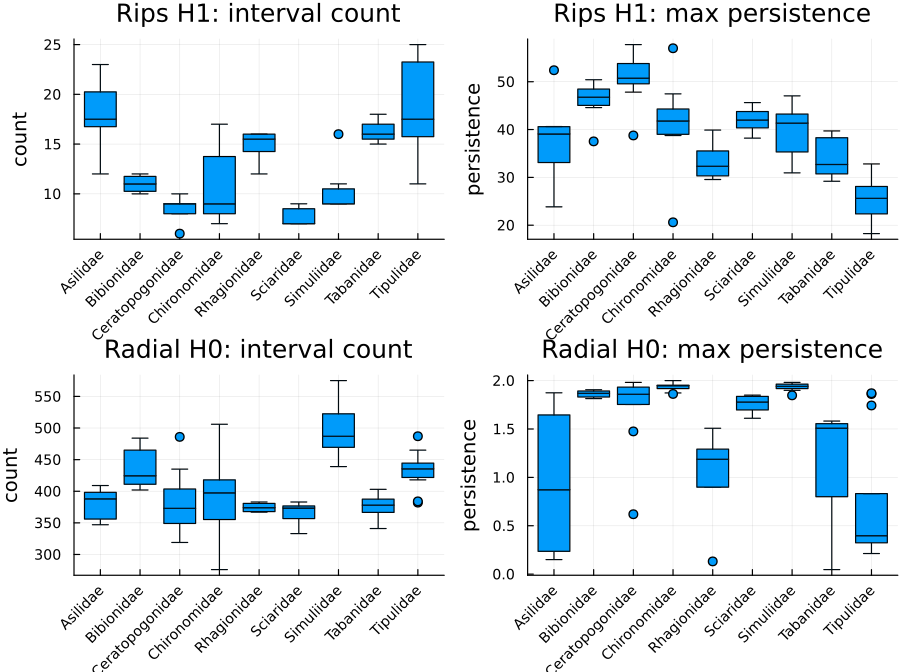

In [10]:
stats_df = DataFrame(
    sample = individuals,
    family = families,
    rips_count = stats_rips[:, 1],
    rips_max_persistence = stats_rips[:, 2],
    radial_count = stats_radial_h0[:, 1],
    radial_max_persistence = stats_radial_h0[:, 2],
)

p1 = boxplot(
    stats_df.family,
    stats_df.rips_count,
    title = "Rips H1: interval count",
    legend = false,
    ylabel = "count",
    xrotation = 45,
)
p2 = boxplot(
    stats_df.family,
    stats_df.rips_max_persistence,
    title = "Rips H1: max persistence",
    legend = false,
    ylabel = "persistence",
    xrotation = 45,
)
p3 = boxplot(
    stats_df.family,
    stats_df.radial_count,
    title = "Radial H0: interval count",
    legend = false,
    ylabel = "count",
    xrotation = 45,
)
p4 = boxplot(
    stats_df.family,
    stats_df.radial_max_persistence,
    title = "Radial H0: max persistence",
    legend = false,
    ylabel = "persistence",
    xrotation = 45,
)
plot(p1, p2, p3, p4, layout = (2, 2), size = (760, 560))

## Classification

We use one classifier: a balanced Random Forest. In each training fold, minority families are upsampled by bootstrap resampling to match the largest family in that fold. Hyperparameters are fixed in advance, so no additional tuning loop is used. The validation procedure is repeated stratified 3-fold cross-validation with 30 repeats.

In [11]:
function stratified_kfolds(labels::Vector{String}; k::Int, rng::MersenneTwister)
    folds = [Int[] for _ in 1:k]
    for cls in sort(unique(labels))
        cls_idx = findall(==(cls), labels)
        shuffle!(rng, cls_idx)
        for (j, idx) in enumerate(cls_idx)
            push!(folds[mod1(j, k)], idx)
        end
    end
    folds
end

function balanced_bootstrap_indices(labels::Vector{String}; rng::MersenneTwister)
    classes = sort(unique(labels))
    target_n = maximum(count(==(cls), labels) for cls in classes)
    idx = Int[]
    for cls in classes
        cls_idx = findall(==(cls), labels)
        append!(idx, rand(rng, cls_idx, target_n))
    end
    shuffle!(rng, idx)
    idx
end

function predict_balanced_rf_fold(
    X_train::Matrix,
    y_train::Vector{String},
    X_test::Matrix;
    n_trees::Int,
    max_depth::Int,
    min_samples_leaf::Int,
    rng::MersenneTwister,
)
    boot_idx = balanced_bootstrap_indices(y_train; rng = rng)
    X_fit = X_train[boot_idx, :]
    y_fit = y_train[boot_idx]
    n_subfeatures = max(1, round(Int, sqrt(size(X_fit, 2))))

    model = build_forest(
        y_fit,
        X_fit,
        n_subfeatures,
        n_trees,
        0.7,
        max_depth,
        min_samples_leaf;
        rng = rng,
    )

    [apply_forest(model, X_test[i, :]) for i in axes(X_test, 1)]
end

function per_class_metrics(y_true::Vector{String}, y_pred::Vector{String})
    classes = sort(unique(y_true))
    rows = NamedTuple[]
    for cls in classes
        tp = count(i -> y_true[i] == cls && y_pred[i] == cls, eachindex(y_true))
        fn = count(i -> y_true[i] == cls && y_pred[i] != cls, eachindex(y_true))
        fp = count(i -> y_true[i] != cls && y_pred[i] == cls, eachindex(y_true))
        precision = tp + fp == 0 ? 0.0 : tp / (tp + fp)
        recall = tp + fn == 0 ? 0.0 : tp / (tp + fn)
        f1 = precision + recall == 0 ? 0.0 : 2 * precision * recall / (precision + recall)
        push!(rows, (
            family = cls,
            support = count(==(cls), y_true),
            recall = recall,
            f1 = f1,
        ))
    end
    DataFrame(rows)
end

function repeated_stratified_rf_cv(
    X::Matrix,
    labels::Vector{String};
    k::Int,
    repeats::Int,
    n_trees::Int,
    max_depth::Int,
    min_samples_leaf::Int,
    rng_seed::Int,
)
    Xclean = sanitize_feature_matrix(X)
    n = size(Xclean, 1)
    repeat_metrics = DataFrame(
        repeat = Int[],
        accuracy = Float64[],
        macro_f1 = Float64[],
        macro_recall = Float64[],
    )
    fold_predictions = DataFrame(
        repeat = Int[],
        fold = Int[],
        sample_index = Int[],
        true_label = String[],
        predicted = String[],
    )
    pooled_true = String[]
    pooled_pred = String[]

    for repeat_id in 1:repeats
        fold_rng = MersenneTwister(rng_seed + repeat_id)
        folds = stratified_kfolds(labels; k = k, rng = fold_rng)
        repeat_pred = Vector{String}(undef, n)

        for fold_id in 1:k
            test_idx = sort(folds[fold_id])
            train_idx = setdiff(1:n, test_idx)
            model_rng = MersenneTwister(rng_seed + 10_000 * repeat_id + fold_id)

            preds = predict_balanced_rf_fold(
                Xclean[train_idx, :],
                labels[train_idx],
                Xclean[test_idx, :];
                n_trees = n_trees,
                max_depth = max_depth,
                min_samples_leaf = min_samples_leaf,
                rng = model_rng,
            )
            repeat_pred[test_idx] = preds

            for (sample_idx, pred) in zip(test_idx, preds)
                push!(fold_predictions, (
                    repeat_id,
                    fold_id,
                    sample_idx,
                    labels[sample_idx],
                    pred,
                ))
            end
        end

        metrics = classification_metrics(labels, repeat_pred)
        push!(repeat_metrics, (
            repeat_id,
            metrics.accuracy,
            metrics.macro_f1,
            metrics.balanced_accuracy,
        ))
        append!(pooled_true, labels)
        append!(pooled_pred, repeat_pred)
    end

    pooled_metrics = classification_metrics(pooled_true, pooled_pred)
    (
        repeat_metrics = repeat_metrics,
        fold_predictions = fold_predictions,
        pooled_true = pooled_true,
        pooled_pred = pooled_pred,
        pooled_metrics = pooled_metrics,
    )
end

repeated_stratified_rf_cv (generic function with 1 method)

In [12]:
cv_results = repeated_stratified_rf_cv(
    X_features,
    labels;
    k = CV_K,
    repeats = CV_REPEATS,
    n_trees = RF_N_TREES,
    max_depth = RF_MAX_DEPTH,
    min_samples_leaf = RF_MIN_SAMPLES_LEAF,
    rng_seed = RNG_SEED,
)

cv_summary = DataFrame(
    metric = ["Macro-F1", "Macro-recall"],
    mean_percent = [
        mean(cv_results.repeat_metrics.macro_f1) * 100,
        mean(cv_results.repeat_metrics.macro_recall) * 100,
    ],
    sd_percent = [
        std(cv_results.repeat_metrics.macro_f1) * 100,
        std(cv_results.repeat_metrics.macro_recall) * 100,
    ],
)

cv_summary.mean_percent = round.(cv_summary.mean_percent, digits = 1)
cv_summary.sd_percent = round.(cv_summary.sd_percent, digits = 1)
cv_summary

The pooled out-of-fold predictions combine all held-out predictions across the 30 repeats. This gives a stable diagnostic view of which families are recovered consistently.

In [13]:
pooled_summary = DataFrame(
    metric = ["Pooled accuracy", "Pooled macro-F1", "Pooled macro-recall"],
    value_percent = round.([
        cv_results.pooled_metrics.accuracy,
        cv_results.pooled_metrics.macro_f1,
        cv_results.pooled_metrics.balanced_accuracy,
    ] .* 100, digits = 1),
)
pooled_summary

In [14]:
family_metrics = per_class_metrics(cv_results.pooled_true, cv_results.pooled_pred)
family_metrics.original_n = [
    count(==(family), labels) for family in family_metrics.family
]
family_metrics.repeated_support = family_metrics.support
family_metrics.recall_percent = round.(family_metrics.recall .* 100, digits = 1)
family_metrics.f1_percent = round.(family_metrics.f1 .* 100, digits = 1)
select!(family_metrics, :family, :original_n, :repeated_support, :recall_percent, :f1_percent)
sort!(family_metrics, :recall_percent)
family_metrics

### Confusion matrix

The confusion matrix below is row-normalized, so each row sums to one and can be read as the distribution of predicted families for a given true family.


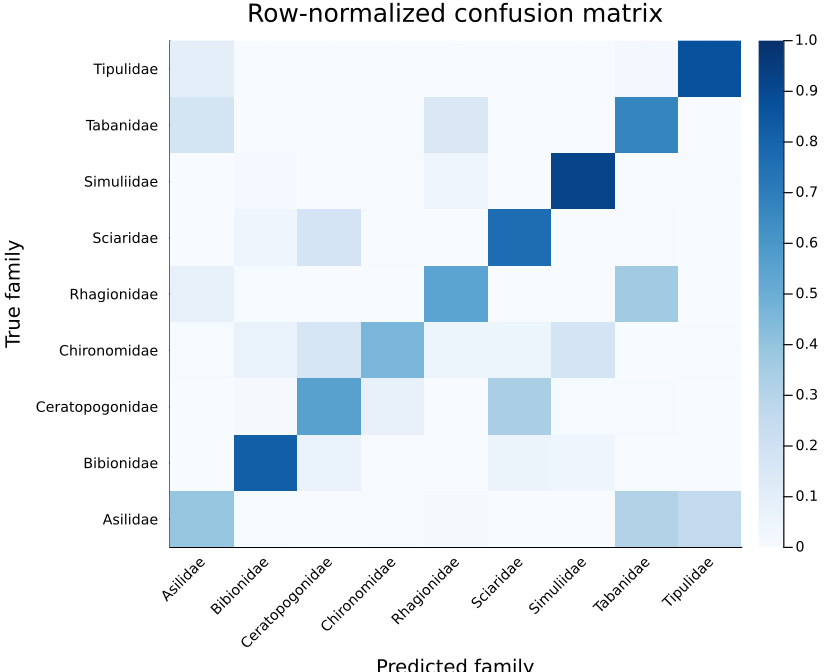

In [15]:
cm_result = confusion_matrix(cv_results.pooled_true, cv_results.pooled_pred)
classes = cm_result.classes
cm_counts = cm_result.matrix
cm_normalized = zeros(Float64, size(cm_counts))
row_totals = vec(sum(cm_counts, dims = 2))

for i in axes(cm_counts, 1)
    if row_totals[i] > 0
        cm_normalized[i, :] = cm_counts[i, :] ./ row_totals[i]
    end
end

heatmap(
    cm_normalized,
    xticks = (1:length(classes), classes),
    yticks = (1:length(classes), classes),
    xlabel = "Predicted family",
    ylabel = "True family",
    title = "Row-normalized confusion matrix",
    color = :Blues,
    clims = (0, 1),
    xrotation = 45,
    size = (700, 560),
)

### Feature importance

Feature importance is descriptive. It is computed from balanced bootstrap trees fit on the full feature matrix, so it should be read as a guide to which topological summaries the Random Forest uses, not as an additional estimate of held-out performance.

In [16]:
rng_imp = MersenneTwister(RNG_SEED)
n_subfeatures_imp = max(1, round(Int, sqrt(size(X_features, 2))))
feature_importance = zeros(size(X_features, 2))

for _ in 1:RF_N_TREES
    boot_idx = balanced_bootstrap_indices(labels; rng = rng_imp)
    tree = build_tree(
        labels[boot_idx],
        X_features[boot_idx, :],
        n_subfeatures_imp,
        RF_MAX_DEPTH,
        RF_MIN_SAMPLES_LEAF,
        2,
        0.0;
        loss = DecisionTree.util.gini,
        rng = rng_imp,
        impurity_importance = true,
    )
    feature_importance .+= DecisionTree.impurity_importance(tree; normalize = false)
end

if maximum(feature_importance) > 0
    feature_importance ./= maximum(feature_importance)
end

importance_df = DataFrame(
    feature = feature_names,
    importance = feature_importance,
)
sort!(importance_df, :importance, rev = true)
top_importance = first(filter(:importance => >(0.0), importance_df), min(15, nrow(importance_df)))
top_importance


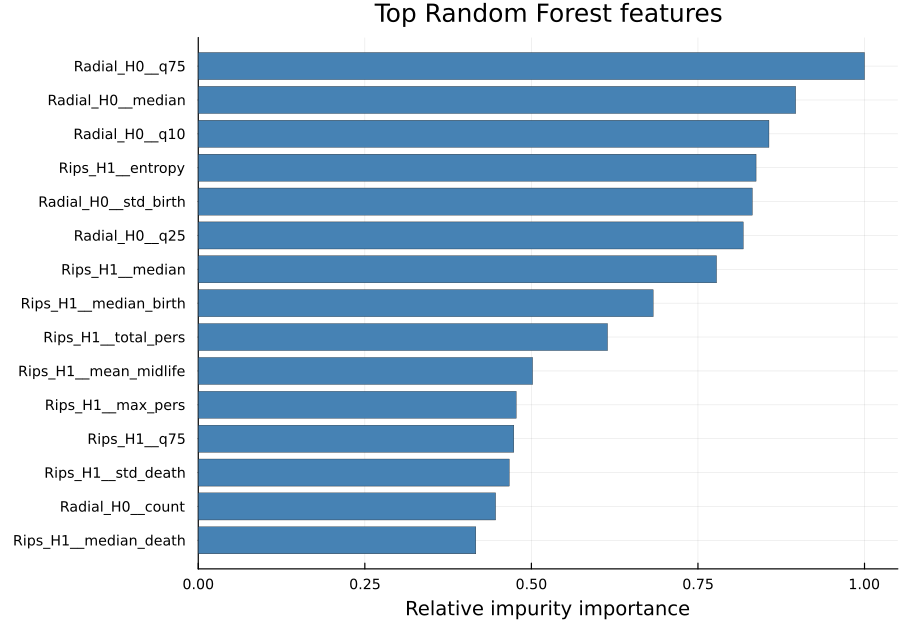

In [17]:
if nrow(top_importance) == 0
    plot(title = "Random Forest feature importance", legend = false)
else
    ord = sortperm(top_importance.importance)
    bar(
        1:length(ord),
        top_importance.importance[ord],
        orientation = :horizontal,
        yticks = (1:length(ord), top_importance.feature[ord]),
        xlabel = "Relative impurity importance",
        title = "Top Random Forest features",
        legend = false,
        color = :steelblue,
        linecolor = :black,
        linewidth = 0.25,
        xlims = (0, 1.05),
        size = (760, 520),
    )
end

### Essential feature reduction

To identify a compact feature set for biological interpretation, we use the Random Forest importance ranking as a reduction path. We evaluate nested subsets of the top-ranked features and select the smallest subset whose screening performance remains within one percentage point of the full 34-feature model for both pooled accuracy and pooled macro-F1. The selected subset is then re-evaluated with the full repeated stratified 3-fold CV configuration.

This procedure is intended to rank features for interpretation. It should not be treated as an independent performance estimate because the feature ranking is learned from the same dataset.

In [18]:
function evaluate_ranked_feature_subsets(
    X::Matrix,
    labels::Vector{String},
    ordered_feature_idx::Vector{Int};
    candidate_sizes::Vector{Int},
    k::Int,
    repeats::Int,
    n_trees::Int,
    max_depth::Int,
    min_samples_leaf::Int,
    rng_seed::Int,
)
    rows = NamedTuple[]
    for n_features in candidate_sizes
        feature_idx = ordered_feature_idx[1:n_features]
        result = repeated_stratified_rf_cv(
            X[:, feature_idx],
            labels;
            k = k,
            repeats = repeats,
            n_trees = n_trees,
            max_depth = max_depth,
            min_samples_leaf = min_samples_leaf,
            rng_seed = rng_seed + 50_000 + n_features,
        )
        push!(rows, (
            n_features = n_features,
            accuracy = result.pooled_metrics.accuracy,
            macro_f1 = result.pooled_metrics.macro_f1,
            macro_recall = result.pooled_metrics.balanced_accuracy,
        ))
    end
    DataFrame(rows)
end

ordered_feature_idx = sortperm(feature_importance, rev = true)
candidate_sizes = collect(1:length(feature_names))

feature_reduction_screen = evaluate_ranked_feature_subsets(
    X_features,
    labels,
    ordered_feature_idx;
    candidate_sizes = candidate_sizes,
    k = CV_K,
    repeats = FEATURE_SCREEN_REPEATS,
    n_trees = FEATURE_SCREEN_N_TREES,
    max_depth = RF_MAX_DEPTH,
    min_samples_leaf = RF_MIN_SAMPLES_LEAF,
    rng_seed = RNG_SEED,
)

full_screen = feature_reduction_screen[feature_reduction_screen.n_features .== length(feature_names), :]
accuracy_threshold = only(full_screen.accuracy) - FEATURE_PERFORMANCE_TOLERANCE
macro_f1_threshold = only(full_screen.macro_f1) - FEATURE_PERFORMANCE_TOLERANCE

eligible_feature_counts = feature_reduction_screen.n_features[
    (feature_reduction_screen.accuracy .>= accuracy_threshold) .&
    (feature_reduction_screen.macro_f1 .>= macro_f1_threshold)
]

essential_n_features = isempty(eligible_feature_counts) ? length(feature_names) : minimum(eligible_feature_counts)
essential_feature_idx = ordered_feature_idx[1:essential_n_features]

essential_cv_results = repeated_stratified_rf_cv(
    X_features[:, essential_feature_idx],
    labels;
    k = CV_K,
    repeats = CV_REPEATS,
    n_trees = RF_N_TREES,
    max_depth = RF_MAX_DEPTH,
    min_samples_leaf = RF_MIN_SAMPLES_LEAF,
    rng_seed = RNG_SEED + 100_000,
)

feature_reduction_summary = DataFrame(
    feature_set = ["All features", "Essential feature set"],
    n_features = [length(feature_names), essential_n_features],
    accuracy_percent = round.([
        cv_results.pooled_metrics.accuracy,
        essential_cv_results.pooled_metrics.accuracy,
    ] .* 100, digits = 1),
    macro_f1_percent = round.([
        cv_results.pooled_metrics.macro_f1,
        essential_cv_results.pooled_metrics.macro_f1,
    ] .* 100, digits = 1),
    macro_recall_percent = round.([
        cv_results.pooled_metrics.balanced_accuracy,
        essential_cv_results.pooled_metrics.balanced_accuracy,
    ] .* 100, digits = 1),
)
feature_reduction_summary

In [19]:
essential_feature_parts = split.(feature_names[essential_feature_idx], "__")
essential_features_df = DataFrame(
    rank = 1:essential_n_features,
    block = getindex.(essential_feature_parts, 1),
    statistic = getindex.(essential_feature_parts, 2),
    relative_importance = round.(feature_importance[essential_feature_idx], digits = 3),
)
essential_features_df


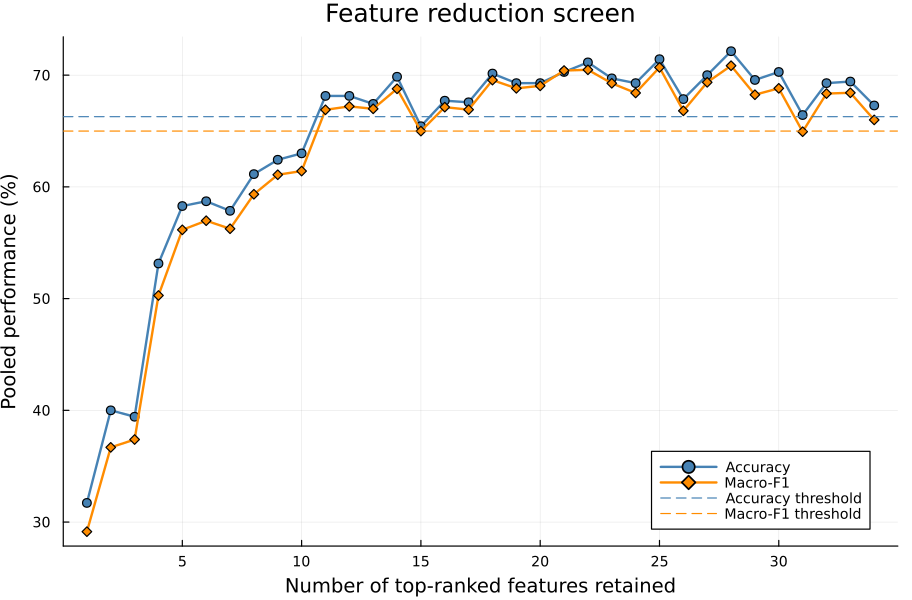

In [20]:
feature_reduction_plot_df = copy(feature_reduction_screen)
plot(
    feature_reduction_plot_df.n_features,
    feature_reduction_plot_df.accuracy .* 100,
    label = "Accuracy",
    xlabel = "Number of top-ranked features retained",
    ylabel = "Pooled performance (%)",
    title = "Feature reduction screen",
    color = :steelblue,
    linewidth = 2,
    marker = :circle,
    legend = :bottomright,
    size = (760, 500),
)
plot!(
    feature_reduction_plot_df.n_features,
    feature_reduction_plot_df.macro_f1 .* 100,
    label = "Macro-F1",
    color = :darkorange,
    linewidth = 2,
    marker = :diamond,
)
hline!(
    [accuracy_threshold * 100],
    label = "Accuracy threshold",
    color = :steelblue,
    linestyle = :dash,
    linewidth = 1,
)
hline!(
    [macro_f1_threshold * 100],
    label = "Macro-F1 threshold",
    color = :darkorange,
    linestyle = :dash,
    linewidth = 1,
)

## Rips Wasserstein distance baseline

Earlier versions of this analysis used a direct distance-matrix approach: compute pairwise Wasserstein distances between the Rips H1 persistence diagrams, then classify by nearest neighbours. We revisit that idea here and add an average-linkage dendrogram. This is a deliberately “pure metric space” baseline because it uses the persistence diagrams only through a single pairwise distance matrix, without extracting interpretable summary features or fitting a flexible classifier.

The Wasserstein constructor has two relevant choices: the Wasserstein order and the ground norm used to match points in the birth-death plane. The previous experiments used the default ground norm, so we compare those settings with Euclidean ground-norm variants.

In [21]:
function rips_wasserstein_distance_matrix(pds; order = 1, ground_norm = Inf)
    distance = Wasserstein(order, ground_norm)
    n = length(pds)
    D = zeros(Float64, n, n)
    @showprogress "rips_wasserstein" for i in 1:n
        for j in (i + 1):n
            D[i, j] = D[j, i] = distance(pds[i], pds[j])
        end
    end
    sanitize_distance_matrix(D)
end

function family_code(family)
    uppercase(first(family, min(3, length(family))))
end

specimen_numbers = [split(individual, "-")[end] for individual in individuals]
dendrogram_labels = [
    "$(family_code(families[i]))$(specimen_numbers[i])" for i in eachindex(families)
]

wasserstein_specs = [
    (distance = "W1_Linf", order = 1, ground_norm = Inf),
    (distance = "W2_Linf", order = 2, ground_norm = Inf),
    (distance = "W1_L2", order = 1, ground_norm = 2),
    (distance = "W2_L2", order = 2, ground_norm = 2),
]

rips_wasserstein_distances = Dict{String, Matrix{Float64}}()
for spec in wasserstein_specs
    rips_wasserstein_distances[spec.distance] = rips_wasserstein_distance_matrix(
        pds_rips;
        order = spec.order,
        ground_norm = spec.ground_norm,
    )
end

The dendrogram below uses average linkage on the W1 distance with the default ground norm. It should be read as an exploratory visualization of the diagram geometry, not as a supervised classifier.


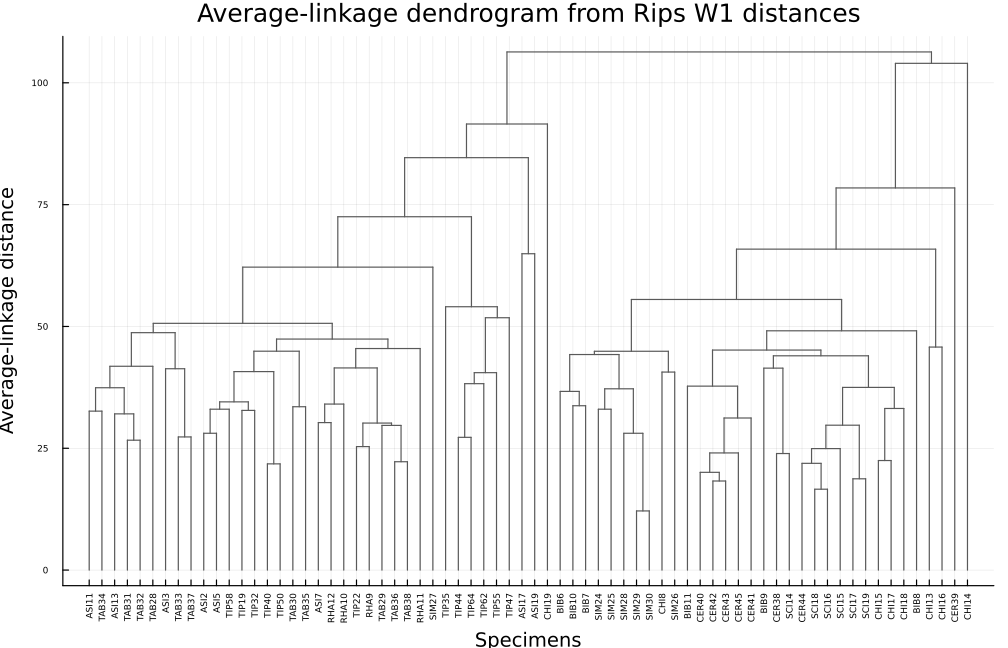

In [22]:
function average_linkage_distance(D, cluster_a, cluster_b)
    total = 0.0
    n_pairs = 0
    for i in cluster_a, j in cluster_b
        total += D[i, j]
        n_pairs += 1
    end
    total / n_pairs
end

function average_linkage_tree(D)
    n = size(D, 1)
    active = Dict(i => [i] for i in 1:n)
    merges = Dict{Int, NamedTuple{(:left, :right, :height), Tuple{Int, Int, Float64}}}()
    next_id = n + 1

    while length(active) > 1
        active_ids = sort(collect(keys(active)))
        best_left = active_ids[1]
        best_right = active_ids[2]
        best_distance = Inf

        for a_pos in 1:(length(active_ids) - 1)
            for b_pos in (a_pos + 1):length(active_ids)
                left_id = active_ids[a_pos]
                right_id = active_ids[b_pos]
                d = average_linkage_distance(D, active[left_id], active[right_id])
                if d < best_distance
                    best_left = left_id
                    best_right = right_id
                    best_distance = d
                end
            end
        end

        if minimum(active[best_left]) > minimum(active[best_right])
            best_left, best_right = best_right, best_left
        end

        merges[next_id] = (left = best_left, right = best_right, height = best_distance)
        active[next_id] = vcat(active[best_left], active[best_right])
        delete!(active, best_left)
        delete!(active, best_right)
        next_id += 1
    end

    (root = only(keys(active)), merges = merges)
end

function dendrogram_order(node, merges, n_leaves)
    node <= n_leaves && return [node]
    merge = merges[node]
    vcat(
        dendrogram_order(merge.left, merges, n_leaves),
        dendrogram_order(merge.right, merges, n_leaves),
    )
end

function plot_average_linkage_dendrogram(D, labels; title_str = "")
    n = size(D, 1)
    tree = average_linkage_tree(D)
    order = dendrogram_order(tree.root, tree.merges, n)
    x_pos = Dict{Int, Float64}(leaf => pos for (pos, leaf) in enumerate(order))
    y_pos = Dict{Int, Float64}(leaf => 0.0 for leaf in 1:n)
    segments = Tuple{Float64, Float64, Float64, Float64}[]

    function collect_segments(node)
        node <= n && return
        merge = tree.merges[node]
        collect_segments(merge.left)
        collect_segments(merge.right)

        xl = x_pos[merge.left]
        xr = x_pos[merge.right]
        yl = y_pos[merge.left]
        yr = y_pos[merge.right]
        h = merge.height

        push!(segments, (xl, xl, yl, h))
        push!(segments, (xr, xr, yr, h))
        push!(segments, (xl, xr, h, h))

        x_pos[node] = (xl + xr) / 2
        y_pos[node] = h
    end

    collect_segments(tree.root)

    p = plot(
        legend = false,
        xlabel = "Specimens",
        ylabel = "Average-linkage distance",
        title = title_str,
        xticks = (1:n, labels[order]),
        xrotation = 90,
        tickfontsize = 5,
        size = (840, 540),
    )
    for (x1, x2, y1, y2) in segments
        plot!(p, [x1, x2], [y1, y2], color = :gray35, linewidth = 1)
    end
    p
end

plot_average_linkage_dendrogram(
    rips_wasserstein_distances["W1_Linf"],
    dendrogram_labels;
    title_str = "Average-linkage dendrogram from Rips W1 distances",
)

To make the comparison with the Random Forest more explicit, we evaluate several distance-based classifiers with the same repeated stratified 3-fold split design used above. The classifier choices are intentionally simple: unweighted k-NN, inverse-distance weighted k-NN, and nearest-family average distance.

In [23]:
function majority_label(label_values::Vector{String})
    counts = Dict{String, Int}()
    for value in label_values
        counts[value] = get(counts, value, 0) + 1
    end
    max_count = maximum(values(counts))
    sort([label for (label, count) in counts if count == max_count])[1]
end

function vote_by_distance(neighbors; weighted = false, fallback = "")
    isempty(neighbors) && return fallback
    if weighted
        weights = Dict{String, Float64}()
        for (distance, label) in neighbors
            weights[label] = get(weights, label, 0.0) + 1.0 / (distance + 1e-8)
        end
        best_weight = maximum(values(weights))
        return sort([label for (label, weight) in weights if weight == best_weight])[1]
    end

    counts = Dict{String, Int}()
    for (_, label) in neighbors
        counts[label] = get(counts, label, 0) + 1
    end
    max_count = maximum(values(counts))
    tied = [label for (label, count) in counts if count == max_count]
    length(tied) == 1 && return only(tied)

    average_distances = Dict(
        label => mean([distance for (distance, neighbor_label) in neighbors if neighbor_label == label])
        for label in tied
    )
    best_distance = minimum(values(average_distances))
    sort([label for (label, distance) in average_distances if distance == best_distance])[1]
end

function predict_distance_knn_fold(D, labels, train_idx, test_idx; k = 1, weighted = false)
    fallback = majority_label(labels[train_idx])
    predictions = Vector{String}(undef, length(test_idx))
    for (out_idx, sample_idx) in enumerate(test_idx)
        neighbors = [
            (D[sample_idx, train_idx_i], labels[train_idx_i])
            for train_idx_i in train_idx
            if isfinite(D[sample_idx, train_idx_i])
        ]
        sort!(neighbors, by = first)
        selected = neighbors[1:min(k, length(neighbors))]
        predictions[out_idx] = vote_by_distance(selected; weighted = weighted, fallback = fallback)
    end
    predictions
end

function predict_distance_centroid_fold(D, labels, train_idx, test_idx)
    classes = sort(unique(labels[train_idx]))
    predictions = Vector{String}(undef, length(test_idx))
    for (out_idx, sample_idx) in enumerate(test_idx)
        class_distances = Dict{String, Float64}()
        for class in classes
            class_idx = [i for i in train_idx if labels[i] == class]
            class_distances[class] = mean(D[sample_idx, class_idx])
        end
        best_distance = minimum(values(class_distances))
        predictions[out_idx] = sort([
            class for (class, distance) in class_distances if distance == best_distance
        ])[1]
    end
    predictions
end

function repeated_stratified_distance_cv(
    D::Matrix,
    labels::Vector{String};
    classifier::Symbol,
    k::Int = 1,
    weighted::Bool = false,
    folds::Int,
    repeats::Int,
    rng_seed::Int,
)
    Dclean = sanitize_distance_matrix(D)
    n = length(labels)
    repeat_metrics = DataFrame(
        repeat = Int[],
        accuracy = Float64[],
        macro_f1 = Float64[],
        macro_recall = Float64[],
    )
    pooled_true = String[]
    pooled_pred = String[]

    for repeat_id in 1:repeats
        rng = MersenneTwister(rng_seed + repeat_id)
        cv_folds = stratified_kfolds(labels; k = folds, rng = rng)
        repeat_pred = Vector{String}(undef, n)

        for fold_id in 1:folds
            test_idx = sort(cv_folds[fold_id])
            train_idx = setdiff(1:n, test_idx)
            fold_pred = if classifier == :centroid
                predict_distance_centroid_fold(Dclean, labels, train_idx, test_idx)
            else
                predict_distance_knn_fold(
                    Dclean,
                    labels,
                    train_idx,
                    test_idx;
                    k = k,
                    weighted = weighted,
                )
            end
            repeat_pred[test_idx] = fold_pred
        end

        metrics = classification_metrics(labels, repeat_pred)
        push!(repeat_metrics, (
            repeat_id,
            metrics.accuracy,
            metrics.macro_f1,
            metrics.balanced_accuracy,
        ))
        append!(pooled_true, labels)
        append!(pooled_pred, repeat_pred)
    end

    pooled_metrics = classification_metrics(pooled_true, pooled_pred)
    (repeat_metrics = repeat_metrics, pooled_metrics = pooled_metrics)
end

distance_classifier_specs = [
    (classifier = :knn, label = "1-NN", k = 1, weighted = false),
    (classifier = :knn, label = "3-NN", k = 3, weighted = false),
    (classifier = :knn, label = "5-NN", k = 5, weighted = false),
    (classifier = :knn, label = "3-NN weighted", k = 3, weighted = true),
    (classifier = :knn, label = "5-NN weighted", k = 5, weighted = true),
    (classifier = :centroid, label = "Nearest family average", k = 1, weighted = false),
]

wasserstein_cv_rows = NamedTuple[]
for spec in wasserstein_specs
    D = rips_wasserstein_distances[spec.distance]
    for classifier_spec in distance_classifier_specs
        result = repeated_stratified_distance_cv(
            D,
            labels;
            classifier = classifier_spec.classifier,
            k = classifier_spec.k,
            weighted = classifier_spec.weighted,
            folds = CV_K,
            repeats = CV_REPEATS,
            rng_seed = RNG_SEED + 200_000,
        )
        push!(wasserstein_cv_rows, (
            distance = spec.distance,
            classifier = classifier_spec.label,
            accuracy = result.pooled_metrics.accuracy,
            macro_f1 = result.pooled_metrics.macro_f1,
            macro_recall = result.pooled_metrics.balanced_accuracy,
        ))
    end
end

wasserstein_cv_results = DataFrame(wasserstein_cv_rows)
sort!(wasserstein_cv_results, [:macro_f1, :macro_recall, :accuracy], rev = true)
wasserstein_cv_results.accuracy_percent = round.(wasserstein_cv_results.accuracy .* 100, digits = 1)
wasserstein_cv_results.macro_f1_percent = round.(wasserstein_cv_results.macro_f1 .* 100, digits = 1)
wasserstein_cv_results.macro_recall_percent = round.(wasserstein_cv_results.macro_recall .* 100, digits = 1)
select(
    first(wasserstein_cv_results, 12),
    :distance,
    :classifier,
    :accuracy_percent,
    :macro_f1_percent,
    :macro_recall_percent,
)

In [24]:
best_wasserstein = wasserstein_cv_results[1, :]
metric_vs_rf_summary = DataFrame(
    method = ["Best Rips Wasserstein baseline", "Balanced Random Forest"],
    representation = ["Rips H1 diagrams as a distance matrix", "Rips H1 + radial H0 summary features"],
    classifier = [best_wasserstein.classifier, "Random Forest"],
    accuracy_percent = round.([
        best_wasserstein.accuracy,
        cv_results.pooled_metrics.accuracy,
    ] .* 100, digits = 1),
    macro_f1_percent = round.([
        best_wasserstein.macro_f1,
        cv_results.pooled_metrics.macro_f1,
    ] .* 100, digits = 1),
    macro_recall_percent = round.([
        best_wasserstein.macro_recall,
        cv_results.pooled_metrics.balanced_accuracy,
    ] .* 100, digits = 1),
)
metric_vs_rf_summary

The direct Wasserstein approach is more than a weak diagnostic baseline. Its best result is close to the feature-based Random Forest: the accuracy differs by about one percentage point, while macro-F1 and macro-recall differ by only a few percentage points. Given the small sample size, this gap should be interpreted cautiously rather than as clear evidence that the Random Forest is decisively superior.

This result suggests that the Rips H1 persistence diagrams already contain substantial family-level signal. The Wasserstein pipeline is also conceptually simple: it keeps the diagrams as diagrams, compares them with an intrinsic distance, and uses nearest-neighbour classification. Its simplicity is mainly statistical and methodological, however, not necessarily computational, because Wasserstein distances require solving optimal matching problems between diagrams.

The feature-based Random Forest remains useful, but for a more modest reason. It combines Rips H1 summaries with radial H0 summaries, can use nonlinear interactions among summary statistics, and gives feature-importance diagnostics for biological interpretation. The present results therefore do not show that a purely metric-space approach is poor. They show that Wasserstein distance is a strong baseline, and that feature extraction plus Random Forest offers a small performance gain together with better interpretability and flexibility.

## Discussion

These results suggest that compact topological summaries of wing venation contain family-level signal. The two retained filtrations capture different information: Vietoris-Rips H1 summarizes global loop structure in the vein network, while radial H0 summarizes how connected vein components organize from the center of the wing outward. The direct Wasserstein baseline strengthens this conclusion: even without radial features or feature extraction, the Rips diagrams alone support competitive classification.

The comparison between Wasserstein distance and Random Forest should be read as a tradeoff, not as a decisive ranking. The Random Forest gives a modest improvement in the current validation, but the gap is small for a dataset of this size. Wasserstein distance therefore remains an important baseline and a useful indication that the persistence diagrams themselves carry taxonomic structure. The advantage of the feature-based Random Forest is that it can combine complementary filtrations and provide interpretable feature rankings, not that it overwhelmingly outperforms the metric-space approach.

The validation design is intentionally conservative for the current dataset. Because the dataset contains only 70 specimens and the family counts are uneven, the primary summaries are macro-F1 and macro-recall rather than overall correct rate. Repeating the stratified 3-fold split 30 times reduces dependence on a single partition and gives a clearer view of which families are stable or ambiguous.

The feature-reduction results provide a candidate set of topological summaries for biological follow-up. Features retained in the essential set should be inspected against wing venation traits, including loop structure, the number of persistent components, and the scale at which vein components merge under the radial filtration.

The main practical limitation is still sample size. Several families have fewer than ten specimens, so family-level recall should be interpreted as provisional. Image quality, binarization, and connectivity correction also affect the persistence diagrams. Follow-up work should add taxonomic context, literature references, and a biological interpretation of the retained topological summaries.